In [1]:
import tempfile

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rc

import litebird_sim as lbs

from scipy.sparse.linalg import cg, LinearOperator
from scipy.interpolate import CubicSpline

import os
from pathlib import Path
os.sys.path.append(str(Path.cwd().parent))

from utils import inpainting_func


In [2]:
plt.rcParams.update({
    "font.size":9,
    "text.usetex":True,
    "font.family":"serif", 
    "font.serif":"Computer Modern Roman"
    })

format = 'pdf'

In [3]:
make_fig_01 = True # Pfs:          frequency power spectra varying fknee and alpha
make_fig_03 = True # toy_inp:      example of inpainted TOD
make_fig_04 = True # Pfs:          frequency power spectra varying fknee and alpha
make_fig_05 = True # Pfs:          frequency power spectra varying fknee and alpha

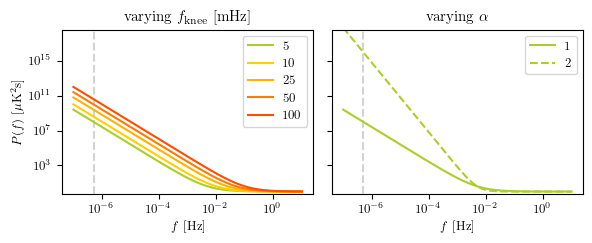

<Figure size 640x480 with 0 Axes>

In [4]:
if make_fig_01 == True:
    sigma = 1
    f_min = 0
    f_knees = [5e-3, 10e-3, 25e-3, 50e-03, 100e-3]
    alphas = [1.0,2.0]

    ff = np.logspace(-7, 1, 1000)

    def spectrum_white(f):
        return sigma**2*np.ones_like(f)

    def spectrum_oof(f, f_knee, alpha):
        return sigma**2*(1 + ((f_knee + f_min)/(f + f_min))**alpha)**2

    spectra_f_knee = []

    for f_knee in f_knees:
        spectra_f_knee.append(spectrum_oof(ff, f_knee, alphas[0]))

    spectra_alpha = []

    for alpha in alphas:
        spectra_alpha.append(spectrum_oof(ff, f_knees[0], alpha))

    colors_f_knee = ["#ACCE29","#FFCF00","#FFB200",'#FF7B00','#FF4E00']
    linestyles_alpha = ["solid", "dashed"]

    y_max = np.max(spectra_alpha[1])
    y_min = np.min(spectra_alpha[1])

    f_chunk_hz = 1/(365.25/16*24*3600)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    ax1.axvline(x=f_chunk_hz, color='lightgray', linestyle='dashed')

    for i in range(len(f_knees)):
        ax1.loglog(ff[ff > 0], spectra_f_knee[i][ff > 0], color=colors_f_knee[i], label=f'{int(1000*f_knees[i])}')

    ax2.axvline(x=f_chunk_hz, color='lightgray', linestyle='dashed')

    for i in range(len(alphas)):
        ax2.loglog(ff[ff > 0], spectra_alpha[i][ff > 0], linestyle=linestyles_alpha[i], color=colors_f_knee[0], label=f'{int(alphas[i])}')

    ax1.set_title(r'varying $f_\mathrm{knee}$ [mHz]')    
    ax1.set_xlabel(r'$f$ [Hz]')
    ax1.set_ylabel(r'$P(f)$ [$\mu$K$^2$s]')
    ax2.set_title(r'varying $\alpha$')    
    ax2.set_xlabel(r'$f$ [Hz]')
    ax2.set_yticklabels([])
    ax1.legend(loc="upper right")
    ax2.legend(loc="upper right")
    ax1.set_ylim(y_min*0.5, y_max*0.6)
    ax2.set_ylim(y_min*0.5, y_max*0.6)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'output/Pfs.{format}')
    plt.clf()

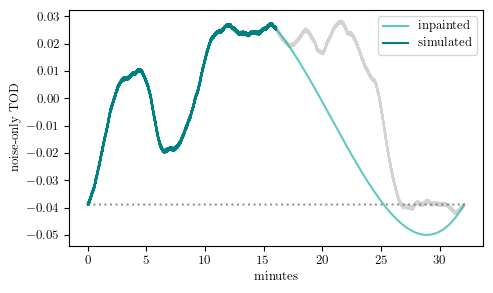

<Figure size 640x480 with 0 Axes>

In [11]:
###############################################################################
####### Producing the input maps, pointings and TODs using litebird_sim #######
###############################################################################

realization = 0

### same sampling rate as for the full simulations
n_samples_pow = 2**29                          
sampling_rate_hz = n_samples_pow/3600/24/365.25 # corresponding to 365.25 days of mission (~17 Hz)

fknee_mhz = 1e2                                 # pessimistic f_knee
alpha = 4                                       # pessimistic alpha
fmin_hz = 1e-8                                  # ~1157 days, longer than the longest chunk we consider (~22.8 days)
net_detector_ukrts = 50.0

###

n_samples_pow = 2**15 # ~2000 seconds of data

###


base_path = 'output'


### Mission parameters
start_time = 51
mission_time_days = n_samples_pow/sampling_rate_hz/3600/24
nsamp_fknee = sampling_rate_hz/(fknee_mhz*1e-3)
nsamp_avg = int(nsamp_fknee//2)


### Simulation parameters
random_seed = realization
imo_version = "vPTEP"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
dtype_float = np.float64
tmp_dir = tempfile.TemporaryDirectory()


### Scanning strategy parameters
spin_sun_angle_deg = 37.5
spin_sun_angle_rad = np.deg2rad(spin_sun_angle_deg)
spin_boresight_angle_rad = np.deg2rad(95-spin_sun_angle_deg)
spin_rate_hz = 0.3 / 60.0
precession_rate_hz = 1/(192.348 * 60)


instr_info = lbs.InstrumentInfo(
    spin_boresight_angle_rad = spin_boresight_angle_rad,
)


ch_info = lbs.FreqChannelInfo(
    bandcenter_ghz=100.0,                   # value for "MF1-100" from Option 1 IMo
    bandwidth_ghz=0.23,                     # value for "MF1-100" from Option 1 IMo
    fwhm_arcmin=20.0,                       # ref value
    net_detector_ukrts=net_detector_ukrts,  # ref value
    fknee_mhz=fknee_mhz,
    fmin_hz=fmin_hz,
    alpha=alpha,
    sampling_rate_hz=sampling_rate_hz,
)


pol_angles_rad = [0., np.pi/2]
n_detectors = len(pol_angles_rad)


### Detector list
detector_list = []
for i in range(n_detectors):
    det = ch_info.get_boresight_detector(name=f"Dummy_det_#{i+1}")
    det.pol_angle_rad = pol_angles_rad[i]
    detector_list.append(det)


################################################################################


### Initializing the simulation
sim = lbs.Simulation(
        random_seed=random_seed,
        base_path=tmp_dir.name,
        name="brahmap_example",
        start_time=start_time,
        duration_s=mission_time_days * 24 * 60 * 60.0,
        imo=imo,
        )


### Create observations
sim.create_observations(
        detectors=detector_list,
        num_of_obs_per_detector=1,
        n_blocks_det=1,
        n_blocks_time=1,
        split_list_over_processes=False,
        tod_dtype=dtype_float,
)
### Adding 1/f noise
lbs.noise.add_noise_to_observations(
    sim.observations, "one_over_f", dets_random=sim.dets_random
)

tod_chunk = np.copy(sim.observations[0].tod[0])

####################################################
# INPAINTING
####################################################

n_samples_sub = 2**14
TOD_oof = tod_chunk[:n_samples_sub]

nsamp_x = n_samples_pow - len(TOD_oof)
fknee_hz = fknee_mhz*1e-3
x_sol = inpainting_func(TOD_oof, nsamp_x, net_detector_ukrts, fknee_hz, alpha, fmin_hz, sampling_rate_hz)

### Plotting and comparing the input and output maps
plt.figure(figsize=(5, 3))
plt.plot(np.arange(n_samples_pow)/sampling_rate_hz/60,tod_chunk, color='lightgray')
plt.plot(len(TOD_oof)/sampling_rate_hz/60+np.arange(nsamp_x)/sampling_rate_hz/60, x_sol, color='lightseagreen', alpha=0.7, label=r'inpainted')
plt.plot(np.arange(n_samples_pow)/sampling_rate_hz/60,np.ones(n_samples_pow)*x_sol[-1], color='dimgrey', alpha=0.7, linestyle=':')
plt.plot(np.arange(len(TOD_oof))/sampling_rate_hz/60,TOD_oof, color='teal', label=r'simulated')
plt.xlabel(r'minutes')
plt.ylabel(r'noise-only TOD')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/toy_inp.pdf")
plt.show()
plt.clf()

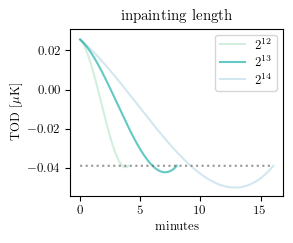

<Figure size 640x480 with 0 Axes>

In [14]:
####################################################
# INPAINTING
####################################################

nsamps_x = [2**12, 2**13, 2**14]
colors = ['#20B35B','lightseagreen','#208BB3']
alphas = [0.2, 0.7, 0.2]

plt.figure(figsize=(3, 2.5))

for i in range(3):
    nsamp_x = nsamps_x[i]
    x_sol = inpainting_func(TOD_oof, nsamp_x, net_detector_ukrts, fknee_hz, alpha, fmin_hz, sampling_rate_hz)
    exp = int(np.log2(nsamp_x))
    plt.plot(np.arange(nsamp_x)/sampling_rate_hz/60,x_sol, color=colors[i], alpha=alphas[i], label=rf"$2^{{{exp}}}$")        

plt.plot(np.arange(nsamp_x)/sampling_rate_hz/60,np.ones(nsamp_x)*x_sol[-1], color='dimgrey', alpha=0.7, linestyle=':')
plt.title(r'inpainting length')
plt.xlabel(r'minutes')
plt.ylabel(r'TOD [$\mu$K]')
plt.ylim(-0.054,0.031)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("output/inp_length.pdf")
plt.show()
plt.clf()

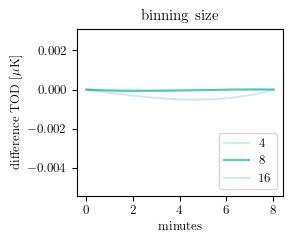

<Figure size 640x480 with 0 Axes>

In [16]:
####################################################
# BINNING
####################################################

nsamp_x = 2**13
n_samp_assumed = nsamp_x + n_samples_sub

x_sol_ref = inpainting_func(TOD_oof, nsamp_x, net_detector_ukrts, fknee_hz, alpha, fmin_hz, sampling_rate_hz)

bin_sizes = [4,8,16]
colors = ['#20B35B','lightseagreen','#208BB3']
alphas = [0.2, 0.7, 0.2]

plt.figure(figsize=(3, 2.5))

for i in range(3):
    bin_size = bin_sizes[i]
    x_sol = inpainting_func(TOD_oof, nsamp_x, net_detector_ukrts, fknee_hz, alpha, fmin_hz, sampling_rate_hz, bin_size)
    plt.plot(np.arange(nsamp_x)/sampling_rate_hz/60, x_sol-x_sol_ref, alpha=alphas[i], color=colors[i], label=f'{bin_size}')

plt.title(r'binning size')
plt.xlabel(r'minutes')
plt.ylabel(r'difference TOD [$\mu$K]')
plt.ylim(-0.0054,0.0031)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("output/bin_size.pdf")
plt.show()
plt.clf()